In [9]:
import math
import matplotlib.pyplot as plt

In [10]:
def read_csv(csv_file):
    with open(csv_file, 'r') as f:
        lines = f.readlines()
        data = []
        for line in lines[1:]:
            row = line.strip().split(',')
            data.append(row)
    return data

data = read_csv('../data/loan2.csv')
print(data)

x1 = [[float(row[0])] for row in data]
x2 = [[float(row[1])] for row in data]
y = [[float(row[2])] for row in data]   
print(f'Experience: {x1}')
print(f'Salary: {x2}')
print(f'y: {y}')

print(f"Shape of Experience: ({len(x1)}, {len(x1[0])})")
print(f"Shape of Salary: ({len(x2)}, {len(x2[0])})")
print(f"Shape of y: ({len(y)}, {len(y[0])})")

[['3', '4', '1'], ['2.5', '4', '1'], ['1', '4', '0'], ['2.5', '5', '1'], ['2', '5', '1'], ['1.5', '5', '0'], ['0.5', '5', '0'], ['1.75', '6', '1'], ['0.25', '6', '0'], ['1', '7', '1'], ['0.25', '7', '0'], ['0.20', '7', '0'], ['0.15', '7', '0'], ['2', '8', '1'], ['1', '8', '0'], ['0.15', '8', '0'], ['0.10', '8', '0'], ['0.5', '9', '1'], ['1', '10', '1']]
Experience: [[3.0], [2.5], [1.0], [2.5], [2.0], [1.5], [0.5], [1.75], [0.25], [1.0], [0.25], [0.2], [0.15], [2.0], [1.0], [0.15], [0.1], [0.5], [1.0]]
Salary: [[4.0], [4.0], [4.0], [5.0], [5.0], [5.0], [5.0], [6.0], [6.0], [7.0], [7.0], [7.0], [7.0], [8.0], [8.0], [8.0], [8.0], [9.0], [10.0]]
y: [[1.0], [1.0], [0.0], [1.0], [1.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [1.0]]
Shape of Experience: (19, 1)
Shape of Salary: (19, 1)
Shape of y: (19, 1)


In [11]:
def sigmoid(z):
    return 1.0 / (1 + math.exp(-z))

def loss_function(N, x1, x2, y, w): # Cross entropy
    total_loss = 0
    for i in range(N):
        y_hat = w[0] + w[1] * x1[i][0] + w[2] * x2[i][0]
        yi = y[i][0]
        total_loss += yi * y_hat - math.log(1 + math.exp(y_hat))
    return - total_loss / N

def gradient(N, x1, x2, y, w):
    grad = [0.0, 0.0, 0.0]
    for i in range(N):
        x1_i = x1[i][0]
        x2_i = x2[i][0]
        yi = y[i][0]
        y_hat = w[0] + w[1] * x1_i + w[2] * x2_i
        grad[0] += 1 - yi - sigmoid(-y_hat)
        grad[1] += -yi*x1_i + x1_i * (1 - sigmoid(-y_hat))
        grad[2] += -yi*x2_i + x2_i * (1 - sigmoid(-y_hat))

    grad[0] = grad[0] / N
    grad[1] = grad[1] / N
    grad[2] = grad[2] / N
    return grad

def gradient_descent(x1, x2, y, lr, threshold=1e-6):
    N = len(y)
    w = [0.0, 1.0, 2.0]
    count = 0
    converged = False
    loss = float('inf')

    while not converged:
        grad = gradient(N, x1, x2, y, w)
        w[0] -= lr*grad[0]
        w[1] -= lr*grad[1]
        w[2] -= lr*grad[2]
        new_loss = loss_function(N, x1, x2, y, w)
        count += 1
        if count % 10000 == 0:
            print(f"Iteration {count}: Loss={new_loss:.3f}")

        if abs(new_loss - loss) < threshold:
            converged = True
            print(f"Model converged after {count} iterations")
        loss = new_loss

    print('Final weights:')
    print(f'w0 = {w[0]:.3f}, w1 = {w[1]:.3f}, w2 = {w[2]:.3f}')
    return w

In [12]:
def plot_logistic_regression(x1, x2, y, w):
    for i in range(len(y)):
        color = 'blue' if y[i][0] else 'red'
        plt.scatter(x1[i][0], x2[i][0], c=color)
    
    x1_min, x1_max = min(x1)[0], max(x1)[0]
    x2_start = -(w[1] * x1_min + w[0]) / w[2]
    x2_end = -(w[1] * x1_max + w[0]) / w[2]

    plt.plot([x1_min, x1_max], [x2_start, x2_end], color='green', label='Boundary')
    x2_min, x2_max = min(x2)[0], max(x2)[0]
    plt.ylim(x2_min - 1, x2_max + 1)
    plt.xlabel('Experience')
    plt.ylabel('Salary')
    plt.show()


Iteration 10000: Loss=0.450
Iteration 20000: Loss=0.426
Iteration 30000: Loss=0.407
Iteration 40000: Loss=0.391
Iteration 50000: Loss=0.377
Iteration 60000: Loss=0.364
Iteration 70000: Loss=0.352
Iteration 80000: Loss=0.342
Iteration 90000: Loss=0.333
Iteration 100000: Loss=0.325
Iteration 110000: Loss=0.318
Iteration 120000: Loss=0.311
Iteration 130000: Loss=0.305
Iteration 140000: Loss=0.299
Iteration 150000: Loss=0.294
Iteration 160000: Loss=0.290
Iteration 170000: Loss=0.286
Iteration 180000: Loss=0.282
Iteration 190000: Loss=0.278
Iteration 200000: Loss=0.275
Iteration 210000: Loss=0.271
Iteration 220000: Loss=0.269
Iteration 230000: Loss=0.266
Iteration 240000: Loss=0.263
Iteration 250000: Loss=0.261
Iteration 260000: Loss=0.259
Iteration 270000: Loss=0.257
Iteration 280000: Loss=0.255
Iteration 290000: Loss=0.253
Iteration 300000: Loss=0.251
Iteration 310000: Loss=0.249
Iteration 320000: Loss=0.248
Iteration 330000: Loss=0.246
Iteration 340000: Loss=0.245
Iteration 350000: Loss=

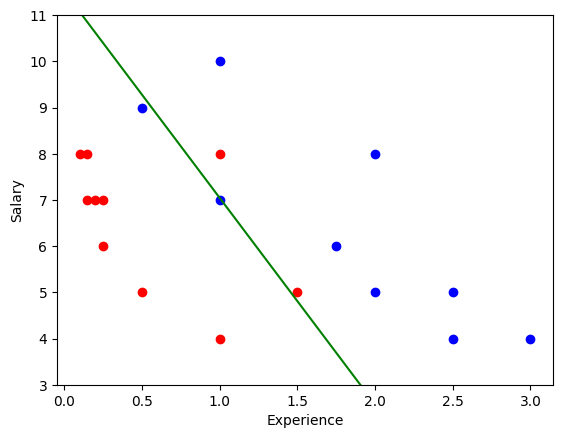

In [13]:
learning_rate = 0.001
threshold = 1e-7
w = gradient_descent(x1, x2, y, lr=learning_rate, threshold=threshold)
plot_logistic_regression(x1, x2, y, w)

In [17]:
def predict(x1_new, x2_new, w):
    predictions = []
    for i in range(len(x1_new)):
        z = w[0] + w[1] * x1_new[i] + w[2] * x2_new[i]
        prob = sigmoid(z)
        y_pred = 1 if prob >= 0.5 else 0
        predictions.append(y_pred)

    return predictions

x1_new = [0.5, 2.0, 1.2, 3.0, 0.2]
x2_new = [3, 6, 8.5, 9, 10]

pred = predict(x1_new, x2_new, w)

for i in range(len(pred)):
    print(f'Data points x1:{x1_new}, x2: {x2_new} => Loan: {pred[i]}')


Data points x1:[0.5, 2.0, 1.2, 3.0, 0.2], x2: [3, 6, 8.5, 9, 10] => Loan: 0
Data points x1:[0.5, 2.0, 1.2, 3.0, 0.2], x2: [3, 6, 8.5, 9, 10] => Loan: 1
Data points x1:[0.5, 2.0, 1.2, 3.0, 0.2], x2: [3, 6, 8.5, 9, 10] => Loan: 1
Data points x1:[0.5, 2.0, 1.2, 3.0, 0.2], x2: [3, 6, 8.5, 9, 10] => Loan: 1
Data points x1:[0.5, 2.0, 1.2, 3.0, 0.2], x2: [3, 6, 8.5, 9, 10] => Loan: 0


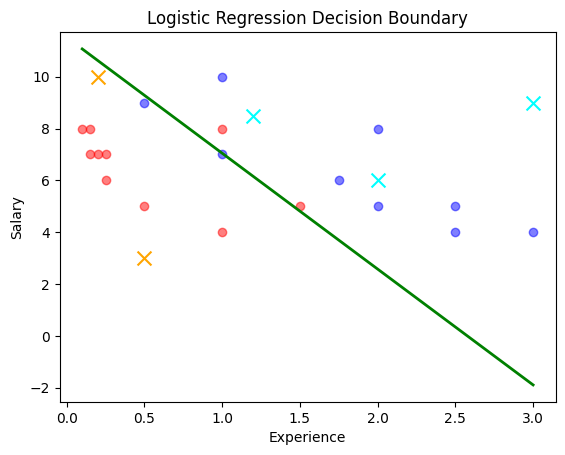

In [19]:
def plot_prediction(x1, x2, y, w, x1_new, x2_new, y_new):
    for i in range(len(y)):
        plt.scatter(x1[i][0], x2[i][0], c='blue' if y[i][0] else 'red', alpha=0.5)
    
    if x1_new:
        for i in range(len(y_new)):
            plt.scatter(x1_new[i], x2_new[i], c='cyan' if y_new[i] else 'orange', marker='x', s=100)

    x1_min, x1_max = min(x1)[0], max(x1)[0]
    x2_start = -(w[1] * x1_min + w[0]) / w[2]
    x2_end = -(w[1] * x1_max + w[0]) / w[2]
    
    plt.plot([x1_min, x1_max], [x2_start, x2_end], color='green', linewidth=2)
    
    plt.xlabel('Experience')
    plt.ylabel('Salary')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

plot_prediction(x1, x2, y, w, x1_new, x2_new, pred)